# Autoencoder on MNIST

An **autoencoder** is a neural network trained to reconstruct its own input. It is made of two parts:
- an **encoder** that compresses the input into a smaller latent representation (bottleneck)
- a **decoder** that reconstructs the original input from that compressed representation

Training minimizes the reconstruction error (e.g. MSE) between the input and the output, forcing the network to learn a compact, meaningful encoding of the data. Here we build a simple fully-connected autoencoder for MNIST digits, compressing each 28x28 image down to a 3-dimensional latent vector.

In [3]:
import os
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image
import matplotlib.pyplot as plt

In [11]:
# Check if MPS is available
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


In [ ]:
#hyperparams
num_epochs = 100
batch_size = 128
lr = 1e-3

In [7]:
def to_img(x):
    x = 0.5*(x+1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

img_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]
)

In [ ]:
# dataset (MINIST)
dataset = MNIST('./data', transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 221kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 827kB/s]


## Model

A symmetric fully-connected encoder/decoder: `784 → 128 → 64 → 12 → 3` and back, with ReLU activations and a final `Tanh` to match the normalized `[-1, 1]` pixel range.

In [25]:
# Autoencoder 
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 12),
            nn.ReLU(True),
            nn.Linear(12, 3)
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(True),
            nn.Linear(12, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [26]:
# Instance
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

## Training

Flatten each image, feed it through the autoencoder, and minimize MSE between input and reconstruction. Every 10 epochs a sample reconstruction is saved to `./mlp_img/`.

In [27]:
if not os.path.exists('./mlp_img'):
    os.mkdir('./mlp_img')

for epoch in tqdm(range(num_epochs)):
    for data in dataloader:
        img, _ = data
        img = img.view(img.size(0), -1)
        img = img.to(device)

        # forward
        output = model(img)
        loss = criterion(output, img)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        pic = to_img(output.data)
        save_image(pic, './mlp_img/image_{}.png'.format(epoch))

torch.save(model.state_dict(), './sim_autoencoder.pth')

100%|██████████| 100/100 [06:32<00:00,  3.93s/it]


## Evaluation

Run the trained model on the test set and visually compare original vs. reconstructed digits.

In [28]:
# test dataset
test_data = MNIST('./data', transform=img_transform, download=True, train=False)
test_dataloader = DataLoader(test_data, batch_size, shuffle=False)

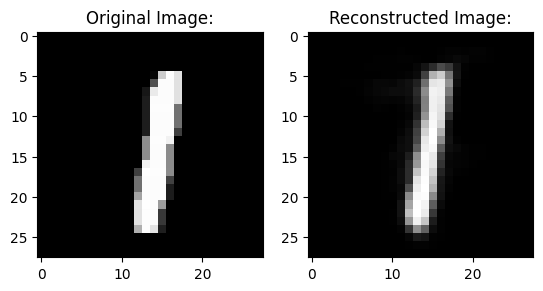

In [30]:
for data in test_dataloader:
    img, _ = data
    img_flat = img.view(img.size(0), -1)
    img_flat = img_flat.to(device)

    output = model(img_flat)
    output = output.detach()

    plt.subplot(1, 2, 1)
    plt.imshow(to_img(img.cpu())[0][0], cmap='gray')
    plt.title("Original Image:")
    plt.subplot(1, 2, 2)
    plt.imshow(to_img(output.cpu())[0][0], cmap='gray')
    plt.title("Reconstructed Image:")